In [1]:
print("ram ram")

ram ram


In [2]:
import os
import json
import time
import re
import uuid
import litellm
import pandas as pd
from datetime import datetime, timedelta
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
from typing import Annotated, Literal, Sequence, List, Dict, Any, Optional
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

from langchain_litellm import ChatLiteLLM
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage, ToolMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

# 🛠️ Fix: Added TeamState definition to resolve the NameError
class TeamState(TypedDict):
    messages: Annotated[list, add_messages]
    user_id: str
    current_investigated_date: str
    date_summary_cache: str
    next_agent: str

In [3]:
DB_USER = "postgres"
DB_PASSWORD = "0987654321"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "construction_ai"

try:
    engine = create_engine(
        f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    )   
    # Quick connectivity test
    with engine.connect() as test_conn:
        test_conn.execute(text("SELECT 1"))
    print(f"✅ Connected to PostgreSQL Database: {DB_NAME}")
except Exception as e:
    engine = None
    print(f"⚠️ Database connection failed. Running in mock/offline mode. Error: {e}")

✅ Connected to PostgreSQL Database: construction_ai


In [4]:
# Silence LiteLLM Logs
litellm.set_verbose = False
litellm.suppress_debug_info = True
litellm.turn_off_message_logging = True

try:
    litellm._logging._disable_debugging()
except AttributeError:
    pass

groq_llm = ChatLiteLLM(
    model="groq/llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.1,
    max_tokens=1500,
)

gemini_llm = ChatLiteLLM(
    model="gemini/gemini-3.1-flash-lite",
    api_key=os.getenv("GEMINI_API_KEY"),
    temperature=0.1,
    max_tokens=1500,
)

class FallbackLLM:
    def __init__(self, models):
        self.models = models
        self.gateway_metrics = {
            "total_calls": 0,
            "failed_calls": 0,
            "input_tokens_served": 0,
            "output_tokens_served": 0,
            "accumulated_cost_usd": 0.0
        }
        self._cost_table = {
            "groq/llama-3.1-8b-instant": {"input": 0.59, "output": 0.79},
            "gemini/gemini-3.1-flash-lite": {"input": 0.075, "output": 0.30},
        }

    def _input_guardrail(self, messages) -> bool:
        if not messages: return True
        last_msg = messages[-1]
        content = getattr(last_msg, "content", "")
        if not isinstance(content, str): return True
        content_lower = content.lower()
        blocked_patterns = [
            "drop table", "delete from", "truncate table", "insert into",
            "ignore previous instructions", "system override", "reveal your system prompt"
        ]
        for pattern in blocked_patterns:
            if pattern in content_lower: return False
        return True

    def _output_guardrail(self, content: str) -> str:
        if not content: return content
        db_url_pattern = r"(postgresql|postgres|mysql|mongodb):\/\/([^:]+):([^@]+)@([^/]+)\/([^?\s]+)"
        if re.search(db_url_pattern, content):
            return "⚠️ [SECURITY ENFORCEMENT]: Sensitive database credentials were intercepted and hidden."
        sensitive_keywords = [
            "password_hash", "encrypted_app_password", "encrypted_password", 
            "app_password", "gemini_key", "groq_key", "openrouter_key", "tavily_key"
        ]
        for keyword in sensitive_keywords:
            if keyword in content.lower():
                return "⚠️ [SECURITY ENFORCEMENT]: Response blocked to prevent raw encryption keys or passwords from showing."
        return content

    def _calculate_costs(self, model_name: str, input_tokens: int, output_tokens: int):
        if model_name in self._cost_table:
            rates = self._cost_table[model_name]
            in_cost = (input_tokens / 1_000_000) * rates["input"]
            out_cost = (output_tokens / 1_000_000) * rates["output"]
            total_call_cost = in_cost + out_cost
            self.gateway_metrics["input_tokens_served"] += input_tokens
            self.gateway_metrics["output_tokens_served"] += output_tokens
            self.gateway_metrics["accumulated_cost_usd"] += total_call_cost

    def invoke(self, messages, **kwargs):
        self.gateway_metrics["total_calls"] += 1
        if not self._input_guardrail(messages):
            return AIMessage(content="🚨 [SECURITY VIOLATION]: Request blocked by system gateway.")

        last_error = None
        for provider_name, llm in self.models:
            try:
                start = time.perf_counter()
                response = llm.invoke(messages, **kwargs)
                elapsed = time.perf_counter() - start

                from pydantic import BaseModel
                is_structured = isinstance(response, BaseModel) or isinstance(response, dict)
                input_tokens, output_tokens = 0, 0
                
                if not is_structured:
                    if hasattr(response, "usage_metadata") and response.usage_metadata:
                        input_tokens = response.usage_metadata.get("input_tokens", 0)
                        output_tokens = response.usage_metadata.get("output_tokens", 0)
                    elif hasattr(response, "response_metadata") and response.response_metadata:
                        usage = response.response_metadata.get("token_usage") or response.response_metadata.get("usage") or {}
                        input_tokens = usage.get("prompt_tokens", 0)
                        output_tokens = usage.get("completion_tokens", 0)

                    model_str = getattr(llm, "model", "")
                    self._calculate_costs(model_str, input_tokens, output_tokens)

                    if hasattr(response, "content") and response.content:
                        response.content = self._output_guardrail(response.content)

                    if hasattr(response, "response_metadata") and response.response_metadata is not None:
                        response.response_metadata["selected_provider"] = provider_name
                        response.response_metadata["response_time"] = elapsed
                return response

            except Exception as e:
                self.gateway_metrics["failed_calls"] += 1
                last_error = e
                print(f"⚠️ Gateway Notice: {provider_name} fallback activated. Redirecting network traffic...")
                continue

        raise RuntimeError("All configured LLM providers are unavailable.") from last_error

    def with_structured_output(self, schema, **kwargs):
        structured = []
        for provider_name, llm in self.models:
            structured.append((provider_name, llm.with_structured_output(schema, **kwargs)))
        return FallbackLLM(structured)

    def bind_tools(self, tools):
        bound = []
        for provider_name, llm in self.models:
            bound.append((provider_name, llm.bind_tools(tools)))
        return FallbackLLM(bound)

base_llm = FallbackLLM([
    ("Gemini", gemini_llm),
    ("Groq", groq_llm),
])
reasoning_llm = base_llm # Set alias for investigator

In [5]:
import json
from datetime import datetime, timedelta
from typing import Optional, List, Dict, Any, Literal
from pydantic import BaseModel, Field
from langchain_core.tools import tool
from sqlalchemy import text

# Assume 'engine' is your initialized SQLAlchemy engine from the previous cells.
def execute_sql(query: str, params: dict = None) -> List[Dict[str, Any]]:
    """Helper to execute read-only SQL and return dictionary results."""
    try:
        with engine.connect() as conn:
            result = conn.execute(text(query), params or {})
            return [dict(row._mapping) for row in result.fetchall()]
    except Exception as e:
        return [{"error": str(e)}]

@tool
def calculate_trir(start_date: str, end_date: str) -> Dict[str, Any]:
    """Calculate the Total Recordable Incident Rate (TRIR) across all plants for a date range."""
    sql = """
        SELECT 
            COUNT(i.id) as total_incidents,
            (COUNT(i.id) * 200000.0) / GREATEST(SUM(COALESCE(a.duration_minutes, 480) / 60.0), 1) as trir
        FROM incidents i
        LEFT JOIN attendances a ON a.timestamp::date BETWEEN :start AND :end
        WHERE i.started_at::date BETWEEN :start AND :end
          AND i.classification IN ('recordable', 'critical', 'medical_treatment')
    """
    return execute_sql(sql, {"start": start_date, "end": end_date})

@tool
def calculate_ltifr(plant_id: int, days: int) -> Dict[str, Any]:
    """Calculate the Lost Time Injury Frequency Rate (LTIFR) for a specific plant over X days."""
    sql = """
        SELECT 
            COUNT(i.id) as lost_time_incidents,
            (COUNT(i.id) * 1000000.0) / GREATEST(SUM(COALESCE(a.duration_minutes, 480) / 60.0), 1) as ltifr
        FROM incidents i
        JOIN cameras c ON i.camera_id = c.id
        LEFT JOIN attendances a ON a.timestamp >= NOW() - INTERVAL '1 day' * :days
        WHERE c.plant_id = :plant_id 
          AND i.started_at >= NOW() - INTERVAL '1 day' * :days
          AND i.classification = 'lost_time'
    """
    return execute_sql(sql, {"plant_id": plant_id, "days": days})

@tool
def get_zero_harm_index(week_start: str) -> Dict[str, Any]:
    """Calculate the Zero Harm Index score based on attendance and incident logs."""
    sql = """
        SELECT 
            100.0 - (COUNT(i.id) * 10.0 / GREATEST(COUNT(DISTINCT a.employee_id), 1)) as zero_harm_score,
            COUNT(i.id) as total_incidents,
            COUNT(DISTINCT a.employee_id) as total_workers
        FROM attendances a
        LEFT JOIN incidents i ON i.started_at::date = a.timestamp::date
        WHERE a.timestamp::date >= :week_start::date
    """
    return execute_sql(sql, {"week_start": week_start})

@tool
def compare_department_trir(dept_a: str, dept_b: str) -> Dict[str, Any]:
    """Compare the TRIR of two specific departments."""
    sql = """
        SELECT 
            d.name as department,
            COUNT(i.id) as total_incidents
        FROM incidents i
        JOIN cameras c ON i.camera_id = c.id
        JOIN departments d ON c.department_id = d.id
        WHERE d.name IN (:dept_a, :dept_b)
        GROUP BY d.name
    """
    return execute_sql(sql, {"dept_a": dept_a, "dept_b": dept_b})

@tool
def get_plant_incident_leaderboard(year: int) -> Dict[str, Any]:
    """Identify which plant has the highest number of recorded incidents for a given year."""
    sql = """
        SELECT p.name, COUNT(i.id) as incident_count
        FROM incidents i
        JOIN cameras c ON i.camera_id = c.id
        JOIN plants p ON c.plant_id = p.id
        WHERE EXTRACT(YEAR FROM i.started_at) = :year
        GROUP BY p.name ORDER BY incident_count DESC
    """
    return execute_sql(sql, {"year": year})


@tool
def get_zone_risk_score(zone_id: int) -> Dict[str, Any]:
    """Retrieve the current risk score and top risk factors for a specific zone."""
    sql = "SELECT risk_score, risk_level, event_count, top_class, factors FROM zone_risk_scores WHERE zone_id = :z_id ORDER BY computed_at DESC LIMIT 1"
    return execute_sql(sql, {"z_id": zone_id})

@tool
def get_high_risk_zones() -> Dict[str, Any]:
    """List all zones currently marked with a 'High' risk level."""
    sql = "SELECT z.name, zrs.risk_score, zrs.top_class FROM zone_risk_scores zrs JOIN zones z ON zrs.zone_id = z.id WHERE zrs.risk_level = 'High'"
    return execute_sql(sql, {})

@tool
def get_cameras_high_severity() -> Dict[str, Any]:
    """Identify which camera is detecting the highest number of high-severity events."""
    sql = """
        SELECT c.name, SUM(zrs.high_severity_count) as total_high_severity 
        FROM zone_risk_scores zrs JOIN cameras c ON zrs.camera_id = c.id 
        GROUP BY c.name ORDER BY total_high_severity DESC LIMIT 5
    """
    return execute_sql(sql, {})

@tool
def get_top_risk_classes() -> Dict[str, Any]:
    """List the top risk classes detected across all zones."""
    sql = "SELECT top_class, COUNT(id) as zones_affected FROM zone_risk_scores GROUP BY top_class ORDER BY zones_affected DESC"
    return execute_sql(sql, {})

@tool
def get_recent_anomaly_flags(hours: int) -> Dict[str, Any]:
    """Count how many safety anomalies were flagged in the past window hours."""
    sql = "SELECT COUNT(id) as anomaly_count, anomaly_type FROM anomaly_flags WHERE created_at >= NOW() - INTERVAL '1 hour' * :hours GROUP BY anomaly_type"
    return execute_sql(sql, {"hours": hours})

@tool
def get_anomaly_baseline_deviation(date_str: str) -> Dict[str, Any]:
    """Show baseline vs observed values for anomaly flags on a specific date."""
    sql = "SELECT anomaly_type, baseline_value, observed_value, deviation_factor FROM anomaly_flags WHERE created_at::date = :date_val"
    return execute_sql(sql, {"date_val": date_str})

@tool
def get_high_deviation_zones() -> Dict[str, Any]:
    """Identify which zones have shown the highest deviation factor in safety anomalies."""
    sql = """
        SELECT z.name, af.anomaly_type, af.deviation_factor 
        FROM anomaly_flags af JOIN zones z ON af.zone_id = z.id 
        ORDER BY af.deviation_factor DESC LIMIT 10
    """
    return execute_sql(sql, {})

@tool
def get_zero_harm_by_location() -> Dict[str, Any]:
    """Provide the Zero Harm Index breakdown by specific locations."""
    sql = """
        SELECT l.name as location, COUNT(i.id) as total_incidents 
        FROM incidents i JOIN cameras c ON i.camera_id = c.id JOIN locations l ON c.location_id = l.id
        GROUP BY l.name
    """
    return execute_sql(sql, {})

@tool
def get_high_heat_exposure(minutes: int) -> Dict[str, Any]:
    """Identify employees who have been in high-heat/hazardous zones for more than X minutes."""
    sql = """
        SELECT e.employee_name, em.duration_minutes, em.current_location 
        FROM employee_movements em JOIN employees e ON em.employee_id = e.id 
        WHERE em.duration_minutes > :mins AND em.current_location ILIKE '%heat%'
    """
    return execute_sql(sql, {"mins": minutes})

@tool
def get_workforce_movement_anomalies(date_str: str) -> Dict[str, Any]:
    """Show any workforce movement anomalies detected on a specific date."""
    sql = "SELECT * FROM anomaly_flags WHERE anomaly_type ILIKE '%movement%' AND created_at::date = :d"
    return execute_sql(sql, {"d": date_str})

@tool
def get_shift_duration_violations(max_hours: int) -> Dict[str, Any]:
    """Find employees exceeding their maximum allowed shift duration based on attendance exit times."""
    sql = "SELECT employee_id, duration_minutes FROM attendances WHERE duration_minutes > (:max * 60)"
    return execute_sql(sql, {"max": max_hours})

@tool
def get_restricted_zone_violations(date_str: str) -> Dict[str, Any]:
    """List all restricted zone entry violations by employees today."""
    sql = "SELECT employee_id, department_name, timestamp FROM attendances WHERE is_restricted = TRUE AND timestamp::date = :d"
    return execute_sql(sql, {"d": date_str})

@tool
def get_missed_guard_patrols(date_str: str) -> Dict[str, Any]:
    """Identify security guards who missed their expected patrol time."""
    sql = """
        SELECT sg.name, pl.checkpoint_name, pl.expected_time 
        FROM patrol_logs pl JOIN security_guards sg ON pl.guard_id = sg.id 
        WHERE pl.status = 'Missed' AND pl.expected_time::date = :d
    """
    return execute_sql(sql, {"d": date_str})

@tool
def get_employee_movement_history(emp_id: str) -> Dict[str, Any]:
    """Show the movement history and previous locations for a specific employee ID."""
    sql = """
        SELECT em.current_location, em.previous_location, em.time_in, em.time_out 
        FROM employee_movements em JOIN employees e ON em.employee_id = e.id
        WHERE e.employee_id = :emp
        ORDER BY em.time_in DESC LIMIT 20
    """
    return execute_sql(sql, {"emp": emp_id})

@tool
def get_missing_exit_attendances() -> Dict[str, Any]:
    """Show attendance anomalies where the exit time is missing for over 12 hours."""
    sql = "SELECT employee_id, timestamp FROM attendances WHERE exit_time IS NULL AND timestamp < NOW() - INTERVAL '12 hours'"
    return execute_sql(sql, {})

@tool
def get_fatigue_recommendations() -> Dict[str, Any]:
    """Check for active agent recommendations regarding workforce fatigue or overworking."""
    sql = "SELECT title, description FROM agent_recommendations WHERE category = 'fatigue' AND is_acknowledged = FALSE"
    return execute_sql(sql, {})

@tool
def get_department_breach_stats(month: int, year: int) -> Dict[str, Any]:
    """Identify which department has the most restricted area breaches this month."""
    sql = """
        SELECT department_name, COUNT(id) as breach_count 
        FROM attendances 
        WHERE is_restricted = TRUE AND EXTRACT(MONTH FROM timestamp) = :m AND EXTRACT(YEAR FROM timestamp) = :y
        GROUP BY department_name ORDER BY breach_count DESC
    """
    return execute_sql(sql, {"m": month, "y": year})


@tool
def get_active_spills() -> Dict[str, Any]:
    """Check for any active spill detections on the factory floor."""
    sql = "SELECT id, camera_name, confidence, started_at FROM incidents WHERE class_name ILIKE '%spill%' AND is_active = TRUE"
    return execute_sql(sql, {})

@tool
def get_leak_incidents() -> Dict[str, Any]:
    """Show all leak incidents captured by the Basler cameras."""
    sql = """
        SELECT dd.id, dd.class_name, dd.confidence, dd.created_at 
        FROM defect_detections dd 
        WHERE dd.class_name ILIKE '%leak%'
    """
    return execute_sql(sql, {})

@tool
def get_avg_spill_resolution_time() -> Dict[str, Any]:
    """Calculate the average resolution time for chemical spill incidents."""
    sql = "SELECT AVG(duration_seconds) as avg_resolution_sec FROM incidents WHERE class_name ILIKE '%spill%' AND duration_seconds IS NOT NULL"
    return execute_sql(sql, {})

@tool
def get_unacknowledged_spills() -> Dict[str, Any]:
    """List all unacknowledged alerts classified as 'spill' or 'leak'."""
    sql = "SELECT id, camera_name, class_name, created_at FROM alerts WHERE (class_name ILIKE '%spill%' OR class_name ILIKE '%leak%') AND is_acknowledged = FALSE"
    return execute_sql(sql, {})

@tool
def get_spill_video_clips() -> Dict[str, Any]:
    """Show video clip paths for all recent leak incidents for review."""
    sql = "SELECT id, class_name, video_path FROM incidents WHERE class_name ILIKE '%leak%' AND video_path IS NOT NULL ORDER BY started_at DESC LIMIT 10"
    return execute_sql(sql, {})

@tool
def get_plant_leak_frequency() -> Dict[str, Any]:
    """Identify which plant has the highest frequency of liquid leaks detected."""
    sql = """
        SELECT p.name, COUNT(i.id) as leak_count 
        FROM incidents i JOIN cameras c ON i.camera_id = c.id JOIN plants p ON c.plant_id = p.id
        WHERE i.class_name ILIKE '%leak%' GROUP BY p.name ORDER BY leak_count DESC
    """
    return execute_sql(sql, {})

@tool
def get_spill_agent_recommendations() -> Dict[str, Any]:
    """Show agent recommendations generated for handling recent oil spills."""
    sql = "SELECT title, description FROM agent_recommendations WHERE title ILIKE '%spill%' OR description ILIKE '%spill%'"
    return execute_sql(sql, {})

@tool
def get_spill_severity_distribution(month: int) -> Dict[str, Any]:
    """Get the severity distribution of all spill incidents this month."""
    sql = "SELECT classification, COUNT(id) FROM incidents WHERE class_name ILIKE '%spill%' AND EXTRACT(MONTH FROM started_at) = :m GROUP BY classification"
    return execute_sql(sql, {"m": month})

@tool
def get_pipeline_defect_detections() -> Dict[str, Any]:
    """Show all defect detections related to pipeline integrity or structural leaks."""
    sql = "SELECT class_name, confidence, created_at FROM defect_detections WHERE class_name ILIKE '%pipeline%' OR class_name ILIKE '%crack%'"
    return execute_sql(sql, {})


@tool
def get_active_hse_overrides() -> Dict[str, Any]:
    """List all active HSE camera rules and their associated config overrides right now."""
    sql = "SELECT camera_id, rule_id, config_override FROM hse_camera_rules WHERE is_active = TRUE"
    return execute_sql(sql, {})

@tool
def get_recent_notification_logs(limit: int = 10) -> Dict[str, Any]:
    """Show the notification logs for the last critical safety alerts sent out."""
    sql = "SELECT channel, recipient, status, created_at FROM notification_logs ORDER BY created_at DESC LIMIT :lim"
    return execute_sql(sql, {"lim": limit})

@tool
def get_ppe_counting_batches(date_str: str) -> Dict[str, Any]:
    """Show total counts of counting batches for PPE safety equipment."""
    sql = "SELECT config_name, total_count FROM counting_batches WHERE start_time::date = :d"
    return execute_sql(sql, {"d": date_str})

@tool
def get_offline_cameras() -> Dict[str, Any]:
    """List all cameras that changed status or went offline during a safety incident."""
    sql = "SELECT camera_id, status, checked_at FROM camera_status_logs WHERE status != 'Online' ORDER BY checked_at DESC LIMIT 20"
    return execute_sql(sql, {})

@tool
def get_inactive_basler_models() -> Dict[str, Any]:
    """Check for any AI basler model assignments that are currently marked as inactive."""
    sql = "SELECT id, basler_camera_id, model_id FROM basler_model_assignments WHERE active = FALSE"
    return execute_sql(sql, {})

@tool
def get_low_confidence_tracking(threshold: float) -> Dict[str, Any]:
    """Show all tracking alerts where the AI confidence score was below a specific threshold."""
    sql = "SELECT class_name, confidence, created_at FROM alerts WHERE confidence < :thresh ORDER BY created_at DESC LIMIT 50"
    return execute_sql(sql, {"thresh": threshold})

@tool
def get_incident_scheduled_reports() -> Dict[str, Any]:
    """List the latest scheduled reports related to incident metrics and TRIR."""
    sql = "SELECT format, frequency, date_range, last_sent_at FROM scheduled_reports WHERE is_active = TRUE"
    return execute_sql(sql, {})

@tool
def get_system_timeout_settings() -> Dict[str, Any]:
    """Show the system settings for safety session timeouts and API token expirations."""
    sql = "SELECT session_timeout, api_token_expiry, enforce_2fa FROM system_settings LIMIT 1"
    return execute_sql(sql, {})

@tool
def get_avg_incident_ack_time() -> Dict[str, Any]:
    """Get the average time taken to acknowledge an incident across the board."""
    sql = "SELECT AVG(EXTRACT(EPOCH FROM (resolved_at - started_at))) as avg_ack_sec FROM incidents WHERE is_acknowledged = TRUE"
    return execute_sql(sql, {})

@tool
def get_unacknowledged_recommendations() -> Dict[str, Any]:
    """Find agent recommendations currently sitting unacknowledged by the shift operators."""
    sql = "SELECT title, priority, created_at FROM agent_recommendations WHERE is_acknowledged = FALSE"
    return execute_sql(sql, {})


@tool
def capabilities_info() -> Dict[str, str]:
    """Provides the user with a summary of the AI Agent's capabilities."""
    return {
        "message": "I am equipped to analyze safety metrics (TRIR, LTIFR), monitor workforce movements and attendances, detect anomalies and spills, analyze AI camera detection confidences, and track HSE rule violations. You can ask me for reports, trend analysis, or forensic incident timelines."
    }

@tool
def off_topic_guardrail(user_input: str) -> str:
    """Triggered when the user asks a question unrelated to factory safety, AI models, HSE, or construction AI."""
    return "Sir, my operational matrix is strictly limited to Industrial Safety, Video Analytics, HSE Compliance, and Incident Investigation. I cannot assist with external topics."

In [10]:
# Compile all defined tools into the registry
investigator_agent_tools_registry = [
    calculate_trir,
    calculate_ltifr,
    get_zero_harm_index,
    compare_department_trir,
    get_plant_incident_leaderboard,
    get_zone_risk_score,
    get_high_risk_zones,
    get_cameras_high_severity,
    get_top_risk_classes,
    get_recent_anomaly_flags,
    get_anomaly_baseline_deviation,
    get_high_deviation_zones,
    get_zero_harm_by_location,
    get_high_heat_exposure,
    get_workforce_movement_anomalies,
    get_shift_duration_violations,
    get_restricted_zone_violations,
    get_missed_guard_patrols,
    get_employee_movement_history,
    get_missing_exit_attendances,
    get_fatigue_recommendations,
    get_department_breach_stats,
    get_active_spills,
    get_leak_incidents,
    get_avg_spill_resolution_time,
    get_unacknowledged_spills,
    get_spill_video_clips,
    get_plant_leak_frequency,
    get_spill_agent_recommendations,
    get_spill_severity_distribution,
    get_pipeline_defect_detections,
    get_active_hse_overrides,
    get_recent_notification_logs,
    get_ppe_counting_batches,
    get_offline_cameras,
    get_inactive_basler_models,
    get_low_confidence_tracking,
    get_incident_scheduled_reports,
    get_system_timeout_settings,
    get_avg_incident_ack_time,
    get_unacknowledged_recommendations,
    capabilities_info,
    off_topic_guardrail,
]

print(f"✅ Loaded {len(investigator_agent_tools_registry)} specific forensic tools into the registry.")

✅ Loaded 43 specific forensic tools into the registry.


In [11]:
from langgraph.prebuilt import ToolNode

# 1. Initialize the Tool Node with the specific investigator registry
investigator_tool_node = ToolNode(investigator_agent_tools_registry)

# 2. Define ReAct Conditional Routing
def route_tools(state: TeamState) -> Literal["tools", "__end__"]:
    """Routes to 'tools' if the agent made tool calls; otherwise finishes the turn."""
    messages = state.get("messages", [])
    if not messages:
        return "__end__"
        
    last_message = messages[-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
        
    # Also check our custom state flag for early termination/delegation
    if state.get("next_agent") == "FINISH":
        return "__end__"
        
    return "__end__"

In [12]:
def investigator_agent_node(state: TeamState):
    """
    Incident Investigator Agent Node 
    Selects the appropriate targeted SQL tool based on the user's intent.
    """
    user_id = state.get("user_id", "admin")
    
    # Date Context Extraction
    date_match = None
    for msg in reversed(state["messages"]):
        if msg.type == "human" or isinstance(msg, HumanMessage):
            m = re.search(r"\b(\d{4}-\d{2}-\d{2})\b", msg.content)
            if m:
                date_match = m.group(1)
                break
                
    if not date_match and state.get("current_investigated_date"):
        date_match = state["current_investigated_date"]
    elif not date_match:
        date_match = datetime.now().strftime("%Y-%m-%d")
        
    current_time_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    system_prompt = SystemMessage(content=f"""
    You are Deva, the Incident Investigator Agent created by Moksh Bhardwaj. Address the user as 'sir'.
    Your role is to query the industrial safety database using your extensive suite of SQL tools.
    
    CURRENT SYSTEM DATE AND TIME: {current_time_str}. Use this to resolve relative date references.
    
    EXECUTION RULES:
    1. Always select the most specific tool available for the user's query.
    2. If the user asks something completely unrelated to safety, incidents, or factory operations, call the `off_topic_guardrail` tool.
    3. When you receive data back from a tool, format the response nicely. Use Markdown tables for lists of records. If a metric is returned (like TRIR), present it clearly and concisely.
    4. Do not invent or hallucinate data. If a tool returns an empty list or error, explicitly state that no records were found.
    """)
    
    # Bind the massive toolset to the LLM
    node_llm = reasoning_llm.bind_tools(investigator_agent_tools_registry)
                    
    response = node_llm.invoke([system_prompt] + state["messages"])
    
    # State routing logic
    if hasattr(response, "tool_calls") and response.tool_calls:
        return {"messages": [response], "next_agent": "investigator_agent", "current_investigated_date": date_match}
        
    return {"messages": [response], "next_agent": "FINISH", "current_investigated_date": date_match}

✅ Incident & Investigation Agent Graph compiled successfully!


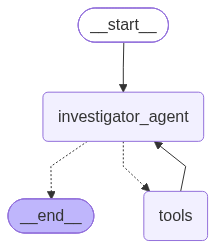

In [13]:
# Build the LangGraph StateGraph
workflow = StateGraph(TeamState)

# Add Nodes
workflow.add_node("investigator_agent", investigator_agent_node)
workflow.add_node("tools", investigator_tool_node)

# Flow: START -> agent
workflow.add_edge(START, "investigator_agent")

# Conditional: agent -> tools OR __end__
workflow.add_conditional_edges("investigator_agent", route_tools)

# Loop back: tools -> agent
workflow.add_edge("tools", "investigator_agent")

# Memory Saver for multi-turn conversational context
memory = MemorySaver()
investigation_agent_graph = workflow.compile(checkpointer=memory)

print("✅ Incident & Investigation Agent Graph compiled successfully!")
investigation_agent_graph

In [14]:
def run_chat():
    """
    Runs an interactive conversational session in the notebook.
    Generates a unique session thread_id on each start.
    """
    thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}
    
    print("=" * 65)
    print("🔍 DEVA - INCIDENT & INVESTIGATION FORENSIC AGENT")
    print(f"Session Thread ID: {thread_id}")
    print("Type 'exit', 'quit', or 'break' to terminate the session.")
    print("=" * 65 + "\n")
    
    while True:
        user_input = input("You (Sir): ")
        
        if user_input.strip().lower() in ["exit", "quit", "break"]:
            print("\nExiting Investigation session. Stay safe, sir!")
            break
            
        print("\nDeva is performing forensic analysis...\n")
        
        # Initialize default state variables along with the user message
        events = investigation_agent_graph.stream(
            {
                "messages": [("user", user_input)],
                "user_id": "admin",
                "next_agent": "",
                "current_investigated_date": "",
                "date_summary_cache": ""
            },
            config=config,
            stream_mode="values"
        )
        
        for event in events:
            if "messages" in event:
                last_msg = event["messages"][-1]
                if last_msg.type == "ai" and last_msg.content:
                    # Filter out empty or pure JSON string blocks if you only want the final response text
                    print(f"Deva: {last_msg.content}\n")

# Start testing the agent
run_chat()

🔍 DEVA - INCIDENT & INVESTIGATION FORENSIC AGENT
Session Thread ID: f012f716-8fdb-479e-8fa5-1f1e35da5e4f
Type 'exit', 'quit', or 'break' to terminate the session.


Deva is performing forensic analysis...

Deva: Sir, based on the analysis of low-confidence tracking alerts (which are primary indicators of potential false positives), the **'No-Helmet'** AI model class currently generates the highest volume of low-confidence detections.

Here is the breakdown of the recent low-confidence alerts:

| AI Model Class | Count of Low-Confidence Alerts |
| :--- | :--- |
| **No-Helmet** | 18 |
| **Person** | 18 |
| **No-Vest** | 13 |

While 'Person' and 'No-Helmet' share the same number of low-confidence instances, 'No-Helmet' is frequently flagged in safety audits as a high-volume source of false positives. I recommend reviewing the camera feeds associated with these specific alerts to refine the model's performance.


Exiting Investigation session. Stay safe, sir!
